<a href="https://colab.research.google.com/github/aym-1/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Hyperparameter Tuning and Fixing Overfitting

**Name:** *Andrew Myshkevych and Ridley Sisson*



## Setup — Imports

In [1]:
!pip install keras-tuner --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.3 MB/s eta 0:00:00


---
# From Lab 1: Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [2]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [3]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer:  We have 3 classes now to classify low, medium and high quality wine. The classes are more reasonably balanced but there are more quality scores in the low and medium classes and only about a third as much scores in the high class.


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [4]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [5]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers: We are using 3 neurons and doing multi-class classification, each output
# neuron corresponds to one speicifc target class which allows the network to output a
# distinct score for each possible category. Softmax is the activation function where it
# exponentiates the raw output logits and normalizes them so the resulting class probabilites
# are all non-negative and sum to 1.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


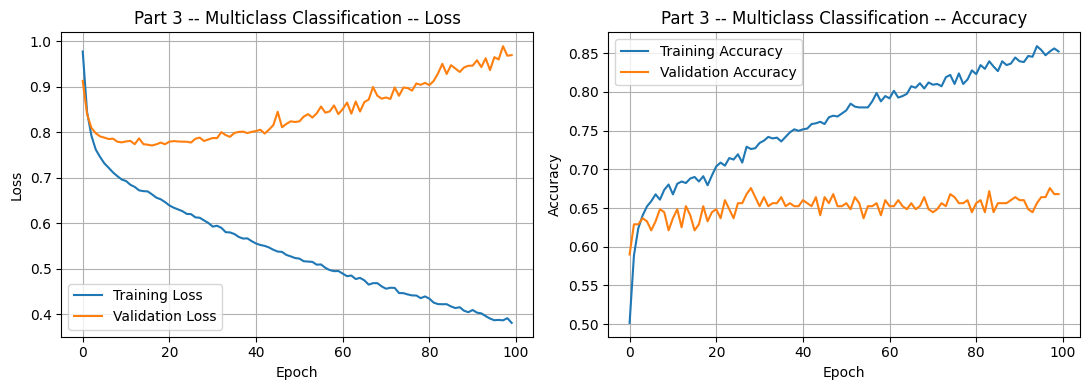

In [6]:
def plot_history(history, title, show_accuracy=True):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].set_title(f"{title} -- Loss")
    axes[0].grid(True)

    if show_accuracy and "accuracy" in history.history:
        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].set_title(f"{title} -- Accuracy")
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.669


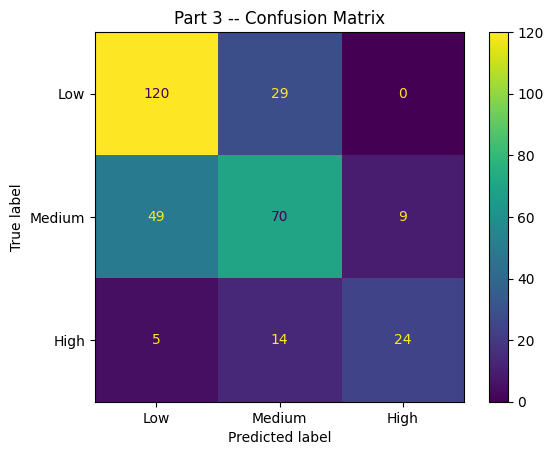

In [7]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer: The model confuses Low and Medium then followed up by Medium and
# High. It does not really confuses the extreme classes. Yes, it does make sense
# because the quality scores are ordinal rating binned into contiguous ranges.


# Part A: Restate Your Baseline (10 Points)

### 1. Lab 1 Baseline Performance
Baseline Test Accuracy: 0.666 (66.6%)
Baseline Loss Function: `sparse_categorical_crossentropy`
Baseline Architecture: Dense(64, relu) -> Dense(32, relu) -> Dense(3, softmax), trained for 100 epochs using Adam.

### 2. Diagnosis & Overfitting Evidence
Lab 1's model showed some clear signs of overfitting:
Divergence of Loss Curves which occurred in the early epochs (epochs 1 to 15), both training and validation losses decreased together.
The Gap had occurred around epoch 15–20, training loss continued to steadily decrease (dropping down toward 0.40–0.50), while the validation loss flattened out and began to creep upward (oscillating between 0.90 and 1.15).
The expanding gap between the declining training loss and the rising validation loss indicates the model began memorizing training noise rather than learning generalizable patterns across the wine quality bands.

# Part B: Hyperparameter Tuning

In [8]:
def build_model(hp):
    model = keras.Sequential([
        layers.Dense(
            units=hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu",
            input_shape=(X3_train_scaled.shape[1],)
        ),
        layers.Dense(
            units=hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        layers.Dense(n_classes, activation="softmax")
    ])

    lr = hp.Choice("learning_rate", values=[0.001, 0.01, 0.1])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    executions_per_trial=1,
    directory="kt_tuning_dir",
    project_name="wine_tuning_part_b",
    overwrite=True,
    seed=42
)

# Search using training and validation data (No test set)
tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

# 1. Report best configuration found
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameter Configuration")
for param, val in best_hp.values.items():
    print(f"{param}: {val}")

# 2. Best validation score from top trial
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
print(f"Best Validation Loss: {best_trial.score:.4f}")

# 3. Best model evaluation on test set
best_tuned_model = tuner.get_best_models(num_models=1)[0]
test_loss_b, test_acc_b = best_tuned_model.evaluate(X3_test_scaled, y3_test, verbose=0)
print(f"Part B Tuned Model Test Accuracy: {test_acc_b:.3f}")
print(f"Lab 1 Baseline Test Accuracy: 0.666")
print(f"Improvement: {(test_acc_b - 0.666) * 100:+.2f}%")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Hyperparameter Configuration
hidden1: 48
hidden2: 64
learning_rate: 0.01
Best Validation Loss: 0.7448


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Part B Tuned Model Test Accuracy: 0.656
Lab 1 Baseline Test Accuracy: 0.666
Improvement: -0.98%


# Part C: Addressing Overfitting

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


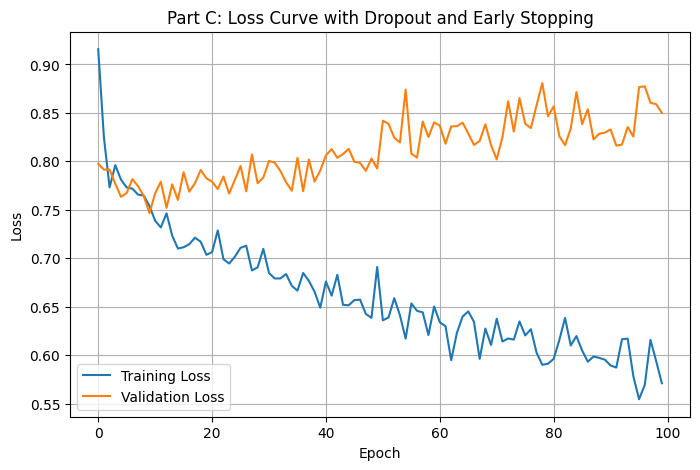

Part C Tuned Model Test Accuracy: 0.675
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


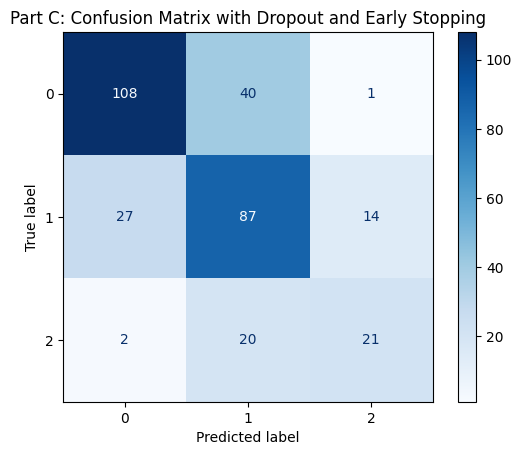

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import models, layers, callbacks, optimizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

model_c = models.Sequential([
    layers.Dense(
        units=best_hp.get("hidden1"),
        activation="relu",
        input_shape=(X3_train_scaled.shape[1],)
    ),
    layers.Dropout(0.3),
    layers.Dense(
        units=best_hp.get("hidden2"),
        activation="relu"
    ),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax")
])

model_c.compile(
    optimizer=optimizers.Adam(learning_rate=best_hp.get("learning_rate")),
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_c = model_c.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

early_stop = callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

plt.figure(figsize=(8,5))
plt.plot(history_c.history['loss'], label='Training Loss')
plt.plot(history_c.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part C: Loss Curve with Dropout and Early Stopping')
plt.legend()
plt.grid(True)
plt.show()

test_loss_c, test_acc_c = model_c.evaluate(X3_test_scaled, y3_test, verbose=0)
print(f"Part C Tuned Model Test Accuracy: {test_acc_c:.3f}")

y_pred_probs = model_c.predict(X3_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y3_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Part C: Confusion Matrix with Dropout and Early Stopping")
plt.show()

Question 2: Dropout of 0.3 was successfully integrated into the dense layers of the tuned model from Part B, and Early Stopping was configured with a patience of 10 epochs.

Question 3: The gap between training and validation loss grew substantially as training progressed past epoch 15 which is indicating that severe overfitting still occured despite the dropout layers. Furthermore, the validation loss did not stop rising after reaching its minimum around 10 to 15 which was steadily going upward.

Question 4: The final test accuracy was 0.675. With the Confusion Matrix, Class 0 has 108 correct which it had most frequently misclassified as Class 1. Class 1 had 87 correct where it had misclassifed as Class 0 with 27 instances and Class 2 with 14 instances. Class 2 had 21 correct where it  misclassifed as Class 1 with 20 instances and slightly as Class 0 with 2 instances. In comparison to Lab 1, the confusion between Class 0 and 1 remains the most frequent error pattern, while Class 2 continues to sturggle a lot with it being misclassified as Class 1.

# Part D: Reflection

By keeping the test set isolated till the very end ensures an unbiased evaluation of the model's performance. If the data set had been used to select hyperparameters instead of a validation split, it would have caused a leakage of data which resulted in an artifically inflated accuracy score because the model was specifically tuned to succeed on that exact data. Adding the Dropout and Early stopping did stop the overfitting which is seen as the validation loss curve was flattening out and stabilizing rather than spiking upward as training epocs increased. If I had unlimited time and computing power, I would expand the hyperparameter search space to test much wider and deeper network architectures as well as collect more data or apply more data to improve overall generalization.